<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/Ex2_State_Space_Analysis/TNS_II_Exercise_2_solved_state_space_k7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# State space analysis


This exercise introduces basic tools for the analysis of dynamic systems. We consider first a linear variant of dynamic systems and later a non-linear variant of a two-dimensional example system, to highlight the similarities and differences.

## Provided functions

You should use the provided function `LinearOrder2()`. This function illustrates, for any two-dimensional linear system you specify,

* the state-space including nullclines and fixed point,
* the evolution of activity from any initial condition,
* the eigenvectors and eigenvalues, and
* state-space and time-evolution together.

Nullclines are curves (often straight lines) in the dynamical system where one of the variables does not change. In other words, they represent points in the space where the rate of change of one or more variables is zero. Fixed points are the intersections of nullclines where no variable changes.

For the non-linear system, you will also need the other provided Python function, `Factivation()`.

## Linear recurrent network

Investigate the time-development of a *linear* recurrent network with $N=2$ populations

$$
\frac{d \textbf{v}}{dt} = \textbf{A} \cdot \textbf{v}  + \textbf{b}
$$
\
$$
\textbf{v}(t) = \begin{pmatrix} v_1(t) \\ v_2(t) \end{pmatrix}, \qquad\qquad  \textbf{A} = \begin{pmatrix} a_{11} & a_{12} \\ a_{21} & a_{22}  \end{pmatrix}= \begin{pmatrix} -2 & 3 \\ -3 & 2  \end{pmatrix}, \qquad\qquad \textbf{b} = \begin{pmatrix} b_1 \\ b_2 \end{pmatrix}
$$
\
from different initial conditions. Note that, in neural terms, this system combines excitation and inhibition. The net effect of the first population is inhibitory, and that of the second population is excitatory. The constant input will be seen to inhibit the first and to excite the second.


##Task A


Choose the constant input vector $\textbf{b}$ such as to obtain the fixed point (which may also be a steady-state)

\
$$
\textbf{v}_\mathit{ss} = \begin{pmatrix} 10 \\ 10 \end{pmatrix}
$$
In other words, solve the fixed point condition for $\textbf{b}$!
$$
0  = \textbf{A} \cdot \textbf{v}_\mathit{ss}  + \textbf{b}
$$

Determine the equations of both nullclines analytically! In other words, obtain the equations of the two lines in state-space that satisfy

$$
\dot v_1 = 0 \qquad\qquad \rm{or} \qquad\qquad \dot v_2 = 0
$$

Determine the point of intersection analytically and numerically and confirm that it corresponds to the fixed point $\textbf{v}_\mathit{ss}$.

Plot the determined nullclines and the calculated $\textbf{v}_\mathit{ss}$ in a single figure.

## Task B

Solve the characteristic equation
$$
\left| \textbf{A} - \lambda \textbf{I} \right| = \left| \begin{pmatrix} a_{11} - \lambda & a_{12} \\ a_{21} & a_{22} - \lambda \end{pmatrix} \right| = (a_{11} - \lambda)(a_{22} - \lambda) - a_{12} a_{21} = 0
$$
for the eigenvalues $\lambda_{1,2}$!

Explain what kind of behavior (stable, unstable, neutral, spiralling, etc) you expect, based on your result?

Use the provided function `LinearOrder2()` to map the state-space and simulate the time-development for some initial condition! Make sure to provide the correct input arguments!

## Non-linear recurrent network

Now make your network non-linear by adding a sigmoidal activation function:

$$
\frac{d \textbf{v}}{dt} = \textbf{F}\left( \textbf{A} \cdot \textbf{v}  + \textbf{b} \right)
$$

where connectivity $\textbf{A}$ and constant input $\textbf{b}$ are identical to the linear network further above.  The non-linear activation function is given by
$$
F(x) = R_\mathit{max} \, \tanh \frac{x}{\kappa} = R_\mathit{max} \, \frac{e^{x/\kappa} - e^{-x/\kappa} }{e^{x/\kappa} + e^{-x/\kappa}}
$$

and is also provided as the function `Factivation()`.  

This non-linear system has the same steady-state and its Jacobean matrix (a matrix of first-order partial derivatives) is proportional to matrix $\textbf{A}$.

Steady-state:
$$
0 = \dot {\textbf{v}}=\textbf{F}(  \textbf{A} \cdot \textbf{v}  + \textbf{b}) \qquad\qquad \Rightarrow \qquad\qquad 0 =  \textbf{A} \cdot \textbf{v}  + \textbf{b}
$$


Jacobean (this part is just for illustrative purposes):

\

$$
\frac{\partial F(x)}{\partial x} = \frac{R_\mathit{max}}{\kappa} \left[1 - F^2(x)\right] \qquad\qquad \Rightarrow \qquad\qquad \left.\frac{\partial F(x)}{\partial x}\right|_{x=0} =  \frac{R_\mathit{max}}{\kappa}\left[1 - F^2(x)\right]_{x=0} =  \frac{R_\mathit{max}}{\kappa}
$$
\
$$
\textbf{J} =  \frac{R_\mathit{max}}{\kappa} \begin{pmatrix}
\partial (v_1 a_{11}+v_2 a_{12} +b_1) / \partial v_1 & \partial (v_1 a_{11}+v_2 a_{12} +b_1) / \partial v_2
\\
\partial (v_1 a_{21}+v_2 a_{22} +b_1) / \partial v_1 & \partial (v_1 a_{21}+v_2 a_{22} +b_1) / \partial v_2
\end{pmatrix}
=
\frac{R_\mathit{max}}{\kappa}
\begin{pmatrix}
a_{11} & a_{12}
\\
a_{21} & a_{22}
\end{pmatrix}
=
 \frac{R_\mathit{max}}{\kappa} \textbf{A}
$$


\
We choose $R_\mathit{max} = 10$ and $\kappa=20$.

## Task C

Simulate the time-evolution of the system for a suitable initial condition, for example:

$$
\textbf{v}_0 = \begin{pmatrix} 9 \\ 9 \end{pmatrix}
$$

After setting the initial activity $\textbf{v}_0$, iteratively compute subsequent activity vectors $\textbf{v}_i$. To this end, proceed from time $0$ to time $10$ in steps of $\Delta t=0.0001$. At each iteration step, compute $\textbf{v}_{i+1}$ from $\textbf{v}_i$ as follows:

\

$$
\textbf{v}_{i+1} = \textbf{v}_{i} + \textbf{F}\left(\textbf{A} \cdot \textbf{v} + \textbf{b}\right) \, \Delta t
$$

\

Save all intermediate results $\textbf{v}_i$ and plot the development as a function of time. Optionally, plot the trajectory also into the state space, superimposed on the isoclines.


Describe the behavior of the system as you change $\kappa$ to $\kappa=50$, or $\textbf{v}_0$ to = $\textbf{v}_0 = \begin{pmatrix} 14 \\ 14 \end{pmatrix}$! How does the frequency and/or the amplitude of the trajectory change?

Calculate and plot the direction of the development from all possible states in the state space in the $\textbf{v}1, \textbf{v}2 \in [5, 15]$ interval


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def Factivation(X, Rmax, kappa):
    return Rmax * np.tanh(X / kappa)

def linear_order2(A: np.ndarray, B: np.ndarray, X0: np.ndarray):

    """
    A is the connectivity matrix
    B is constant input to our system
    X0 is the initial point for our trajectory
    """

    statesize = 10
    tend = 10

    # Calculate the steady state
    Xss = np.linalg.solve(A, -B)

    # Perform eigendecomposition of the connectivity matrix A
    eigvals, eigvecs = np.linalg.eig(A)
    lambda1, lambda2 = eigvals
    E1, E2 = eigvecs[:, 0], eigvecs[:, 1]

    xmin = np.floor(Xss[0] - statesize)
    xmax = np.ceil(Xss[0] + statesize)
    xi = np.linspace(xmin, xmax, 100)

    ydx0i = -(A[0, 0] * xi + B[0]) / A[0, 1]
    ydy0i = -(A[1, 0] * xi + B[1]) / A[1, 1]

    ymin = np.floor(min(ydx0i.min(), ydy0i.min()))
    ymax = np.ceil(max(ydx0i.max(), ydy0i.max()))

    xv = np.linspace(xmin, xmax, 10)
    yv = np.linspace(ymin, ymax, 10)
    XV, YV = np.meshgrid(xv, yv)
    DXV = A[0, 0] * XV + A[0, 1] * YV + B[0]
    DYV = A[1, 0] * XV + A[1, 1] * YV + B[1]

    t = np.linspace(0, tend, 100)
    Xi = np.zeros((2, len(t)))
    C = np.linalg.solve(eigvecs, X0 - Xss)
    Xi[0, :] = np.real(C[0] * E1[0] * np.exp(lambda1 * t) + C[1] * E2[0] * np.exp(lambda2 * t) + Xss[0])
    Xi[1, :] = np.real(C[0] * E1[1] * np.exp(lambda1 * t) + C[1] * E2[1] * np.exp(lambda2 * t) + Xss[1])

    plt.figure()
    plt.plot(xi, ydx0i, 'r', linewidth=2, label='dx/dt=0')
    plt.plot(xi, ydy0i, 'b', linewidth=2, label='dy/dt=0')
    plt.quiver(XV, YV, DXV, DYV, color='k', linewidth=1)
    plt.plot(Xi[0, :], Xi[1, :], 'g', linewidth=4, label='Trajectory')
    plt.plot(Xss[0], Xss[1], 'k+', markersize=10, linewidth=2, label='Steady-state')
    plt.axhline(0, color='k', linestyle=':', linewidth=2)
    plt.axvline(0, color='k', linestyle=':', linewidth=2)
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

    plt.figure()
    plt.plot(t, Xi[0, :], 'r', linewidth=2, label='x(1)')
    plt.plot(t, Xi[1, :], 'b', linewidth=2, label='y(1)')
    plt.axhline(Xss[0], color='r', linestyle='--', linewidth=1, label='x_ss')
    plt.axhline(Xss[1], color='b', linestyle='--', linewidth=1, label='y_ss')
    plt.axhline(0, color='k', linestyle=':', linewidth=2)
    plt.legend()
    plt.xlabel('t')
    plt.ylabel('x, y')
    plt.show()

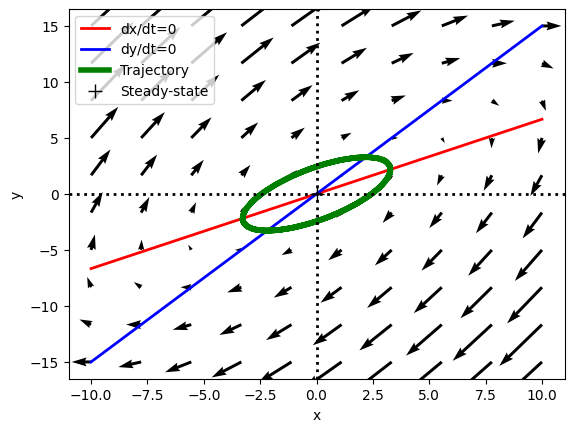

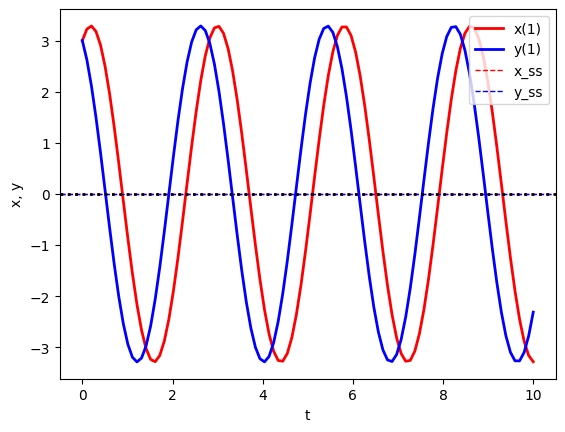

In [ ]:
# Showcasing how the function works with some random values
linear_order2(A = np.array([[-2, 3], [-3, 2]]), B = np.array([0, 0]), X0 = np.array([3, 3]))

TNS exercise 2 SOLVED - KEERTHI

The external input b = [-10  10]
the fixed point that satisfies intersection and fixed point condition = [10. 10.]


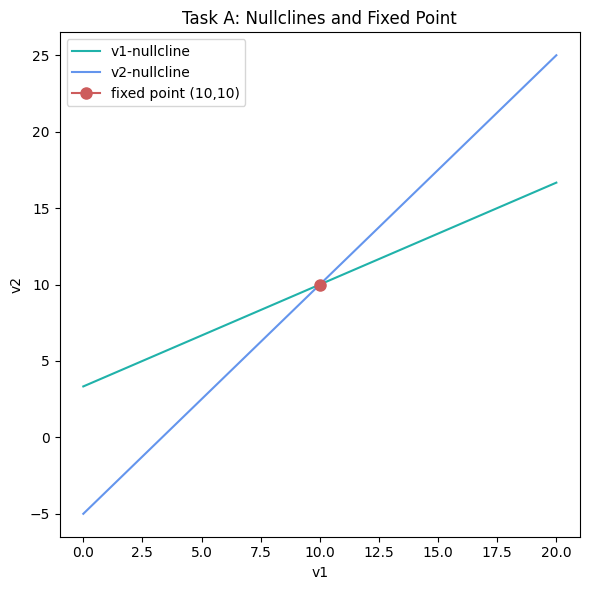

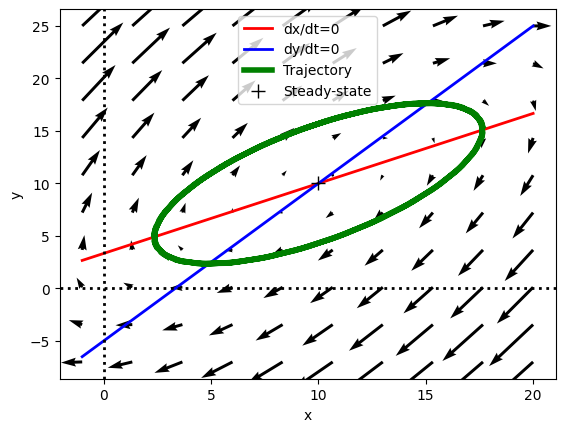

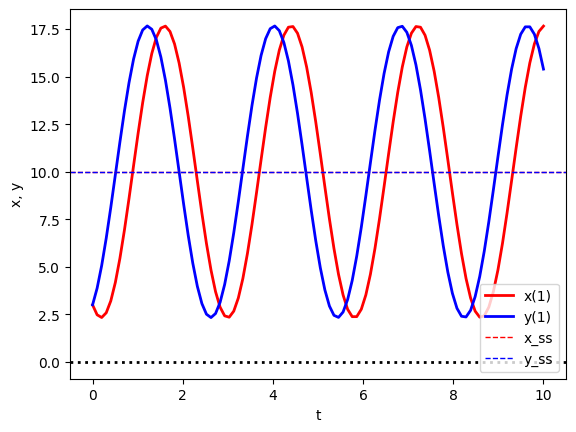

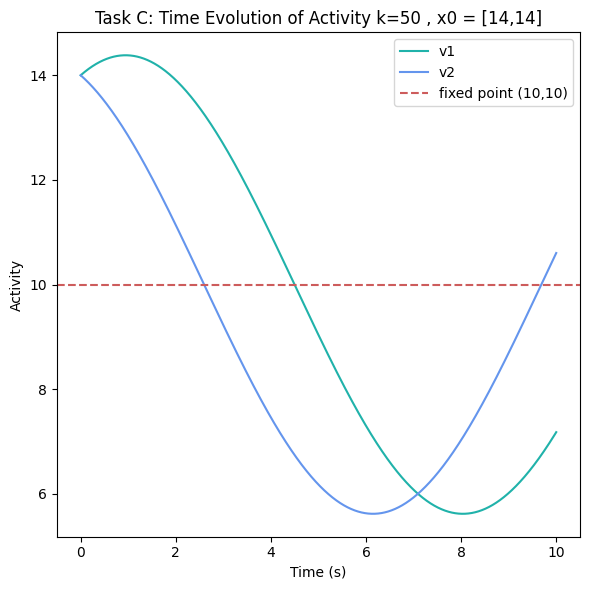

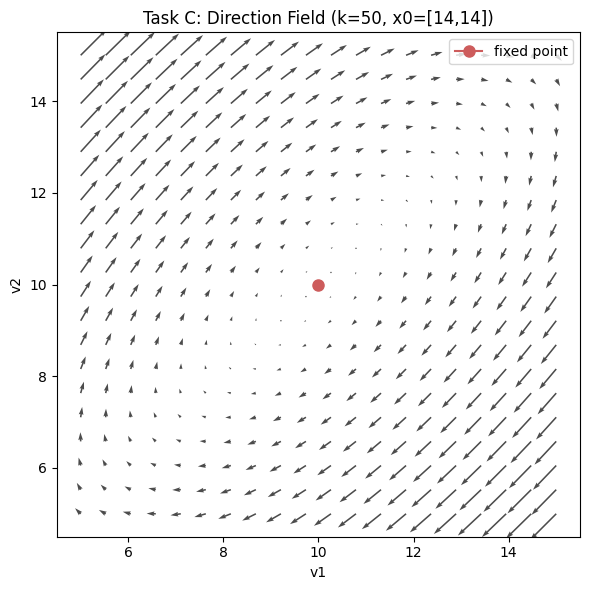

In [ ]:
#STATE SPACE ANALYSIS SOLVED
import numpy as np
import matplotlib.pyplot as plt

#we have a network of neurons comprising 2 populations that have activity rates that change over time
#we want to see the activity vector v = [v1(t), v2(t)]Transpose (changes it to column form) evolve over time in the
#state space, ie - v1-v2 plane. Every possible state of my system is a single point on this plane, activities change
#and the system moves through this plane on a TRAJECTORY


#A is our connectivity matrix which encodes the interactions between the two populations of neurons (the columns)
#the rows in the matrix signify what causes the changes in activity for each population i.e. v1 and v2
#so the rows denote the input signals that each population receives (from itself and population 2) and
#how strong each connection is.

#v1 arrives at connection matrix A, the signal from population in in row is is -2, so it inhibits
#itself because it is a negative value and it receives the signal of strength 3 from population 2
#which means that the effect of population 2 on population 1 is strong and positive

"""the equation of motion: dv/dt = A*v + b where A is the matrix, v is activity and b is a constant
#external input, this equation denotes the rate of change of activity equals the network's influence
on itself plus external input, so at every point in time, the dynamic equation of motion tells me
how fast and in which direction my activity vector is changing

- Fixed point: a fixed point is a state where the rate of change is 0, a fixed point could also be a
steady state. So, at v_ss, dv/dt = 0. Plug 0 into the equation of motion and we get the equation for
FIXED POINT CONDITION : A*v_ss + b = 0 where the activity vector comprised of the activity levels for
both populations, which is why we have v1 and v2, - IS 0, no activity happens at v_ss.

-A nullcline is just a geometrical line in the v1-v2 space where one of the activity levels are 0,
if v1 is 0, v2 could still be working. So they're points in the plane where they are momentarily
'frozen'
At the point in the plane where both intersect, we have our
fixed point.

Given to us: v_ss = [10 10], what should the external vector input (b) be to make this happen

From the fixed point condition 0 = A * v_ss +  b [we solve for b]
-A * v_ss = b (rearrange terms by isolating b)

#we just multiply A by the desired fixed point and 'flip the sign'

#upon computing by hand, b = [-10 10]"""


#Task A

#set up connectivity matrix A
A = np.array([[-2,3],[-3,2]])

#desired fixed point v_ss

v_ss = np.array([10, 10])

#compute b from fixed point condition b = -A * v_ss (@ is the matrix multiplication operator in numpy)
b = -A @ v_ss

print(f'The external input b = {b}') #should show [-10,10]

#calculate fixed_point using np.linalg.solve(A,-b)
"""it solves the equation A*v_ss = -B and finds the point satisfying both nullcline equations smltaneously
satisfying both nullclines at once = satisfying fixed point condition
np.linal.solve finds intersection of 2 nullclines by treating them as a system of 2 equations with
2 unknowns"""

v_fixed = np.linalg.solve(A, -b)
print(f'the fixed point that satisfies intersection and fixed point condition = {v_fixed}')
#shows [10 10]
#THEREFORE, THE POINT OF INTERSECTION INDEED CORRESPONDS TO FIXED POINT V_SS
#Plot determined nullclines and calculated v_ss in a single figure

#set up nullclines to plot across v1-v2 plane
v1 = np.linspace(0, 20, 100) #creates 100 evenly spaced v1 values between 0 and 20.
#these are points along the horizontal axis of my state space plane

#v1 nullcline: v2 = (10+2v1)/3 derived from row 1 of fixed point condition eq, we set v to 0
#we represent v2 as fn of v1 in order to plot a line even
nullcline_1 = (10+2*v1)/3

#v2-nullcline: 3v1-10/3
nullcline_2 = (3*v1 -10)/2

#for each of the 100 v1 values between 0 and 20, numpy will compute the corresponding v2 value
#so we get 100 pairs of points

#why 0-20? because our fixed point is at 10 and this range centres well on the plot
#so its just for convenience +

#plotting our nullclines

fig, ax = plt.subplots(figsize=(6,6))

#plot nullclines
ax.plot(v1, nullcline_1, color ='lightseagreen', label = 'v1-nullcline')
#ax.plot plots v1 on the x axis and v2 values on y axis
#meaning the nullcline is a line

ax.plot(v1, nullcline_2, color='cornflowerblue',label='v2-nullcline')

#plot our fixed point
ax.plot(v_fixed[0], v_fixed[1], marker='o',markersize = '8', color='indianred', label = 'fixed point (10,10)')
#v_fixed[0] and v_fixed[1] indexes into the fixed point vector, 0 gives 10 ie v1 and 1 gives 10 ie v2

#the nullclines are reference lines themselves

#plot labels and legends
ax.set_xlabel('v1')
ax.set_ylabel('v2')
ax.set_title('Task A: Nullclines and Fixed Point')
ax.legend()
plt.tight_layout()


#TASK B: Solve the characteristic equation |A-lamI|=0 to find the eigenvalues of A and determine the stability of the fixed point.


#where, A's diagonal matrix values are a_11-lam and a22-lam
#we compute the determinant of such a matrix (2x2) with the formula
#AD-BC : which are the diagonal values inside A multiplied and then subtracted


#I found that eigenvalues lam1 and lam 2 = ±sqrt(-5)
#however, we cannot actually take the square root of our original result -5
#this is why we use the imaginary number i because by definition the sqrt(-1)=i
#therefore, lam 1 is +i*sqrt(5) and lam 2 is -i*sqrt(5)

#The property of my matrix A is such that its diagonal entries are exact opposites of each other albeit having the same magnitude.
#the real part ie the trace of the matrix A (sum of diagonal elements) is 0
#the determinant of such a matrix is +i * sqrt(5) * -i*sqrt(5)
#and there exists a relationship between the trace and determinant of a matrix and its eigenvalues, which is that the trace is equal to the sum of the eigenvalues and the determinant is equal to the product of the eigenvalues.
#so, in our case, the trace is 0 because the eigenvalues are complex conjugates of each other, meaning they have the same magnitude but opposite signs in their imaginary parts, which results in their sum being zero.
#there exists no real number that satisfies the characteristic equation, which is why we have to use complex numbers to express the eigenvalues.

#and imaginary eigenvalues indicate that the system will exhibit oscillatory behavior, as the complex conjugate eigenvalues correspond to oscillations in the state space.
# The real part of the eigenvalues determines whether the oscillations grow, decay, or remain constant in amplitude over time.
# In our case, since the real part is zero, the oscillations will neither grow nor decay, resulting in a neutrally stable system with spiraling trajectories around the fixed point.
#this is known as neutrally stable with spiralling, because the system will oscillate around the fixed point without converging to it or diverging away from it.

#the function linear_order2() was given to us


def Factivation(X, Rmax, kappa):
    return Rmax * np.tanh(X / kappa)

def linear_order2(A: np.ndarray, B: np.ndarray, X0: np.ndarray):

    """
    A is the connectivity matrix
    B is constant input to our system
    X0 is the initial point for our trajectory
    """

    statesize = 10
    tend = 10

    # Calculate the steady state
    Xss = np.linalg.solve(A, -B)

    # Perform eigendecomposition of the connectivity matrix A
    eigvals, eigvecs = np.linalg.eig(A)
    lambda1, lambda2 = eigvals
    E1, E2 = eigvecs[:, 0], eigvecs[:, 1]

    xmin = np.floor(Xss[0] - statesize)
    xmax = np.ceil(Xss[0] + statesize)
    xi = np.linspace(xmin, xmax, 100)

    ydx0i = -(A[0, 0] * xi + B[0]) / A[0, 1]
    ydy0i = -(A[1, 0] * xi + B[1]) / A[1, 1]

    ymin = np.floor(min(ydx0i.min(), ydy0i.min()))
    ymax = np.ceil(max(ydx0i.max(), ydy0i.max()))

    xv = np.linspace(xmin, xmax, 10)
    yv = np.linspace(ymin, ymax, 10)
    XV, YV = np.meshgrid(xv, yv)
    DXV = A[0, 0] * XV + A[0, 1] * YV + B[0]
    DYV = A[1, 0] * XV + A[1, 1] * YV + B[1]

    t = np.linspace(0, tend, 100)
    Xi = np.zeros((2, len(t)))
    C = np.linalg.solve(eigvecs, X0 - Xss)
    Xi[0, :] = np.real(C[0] * E1[0] * np.exp(lambda1 * t) + C[1] * E2[0] * np.exp(lambda2 * t) + Xss[0])
    Xi[1, :] = np.real(C[0] * E1[1] * np.exp(lambda1 * t) + C[1] * E2[1] * np.exp(lambda2 * t) + Xss[1])

    plt.figure()
    plt.plot(xi, ydx0i, 'r', linewidth=2, label='dx/dt=0')
    plt.plot(xi, ydy0i, 'b', linewidth=2, label='dy/dt=0')
    plt.quiver(XV, YV, DXV, DYV, color='k', linewidth=1)
    plt.plot(Xi[0, :], Xi[1, :], 'g', linewidth=4, label='Trajectory')
    plt.plot(Xss[0], Xss[1], 'k+', markersize=10, linewidth=2, label='Steady-state')
    plt.axhline(0, color='k', linestyle=':', linewidth=2)
    plt.axvline(0, color='k', linestyle=':', linewidth=2)
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

    plt.figure()
    plt.plot(t, Xi[0, :], 'r', linewidth=2, label='x(1)')
    plt.plot(t, Xi[1, :], 'b', linewidth=2, label='y(1)')
    plt.axhline(Xss[0], color='r', linestyle='--', linewidth=1, label='x_ss')
    plt.axhline(Xss[1], color='b', linestyle='--', linewidth=1, label='y_ss')
    plt.axhline(0, color='k', linestyle=':', linewidth=2)
    plt.legend()
    plt.xlabel('t')
    plt.ylabel('x, y')
    plt.show()

#the function signature is linear_order2(A, B, X0). Where, A is the connectivity matrix
#B is the external input vector [-10 10], computed above and X0 is the initial condition
#from where the trajectory starts

#we must choose an initial condition. Since the fixed point is at (10,10), we can start nearby
#but no exactly on the fixed point : so, (3,3) for instance

X0 = np.array([3,3])

#call the provided function
linear_order2(A=A, B=b, X0=X0)
plt.show()

#what we expect to see from the plots of Task B
#plot 1- State Space
""" The green trajectory is a closed loop that orbits around the fixed point (10,10) which is marked with a cross
It never spirals inward or outward, it orbits as such until the end of time. The arrows show the flow
direction at every point in the state space - ie they push the trajectory together, around in a circle
The red and blue lines are our nullclines crossing at the fixed point which we plotted in Task A"""

#plot 2 - time evolution
""" Both v1 and v2 oscillate forever with a constant amplitude, they don't grown or decay.
they're basically sine waves that are almost at par with each other. the dashed blue line at y=10
is the fixed point.
So, the system orbits around it but never reaches it. """

#therefore the behaviour is neutral stability with spiralling,
# and at any point a slight push would make it spiral inward or outward
#we predicted the imaginary part of the eigenvalue to be responsible for making the system spiral
#if the real part were 2 then it the trajectory would be scaled by 2 or if it was 0, there would be
#no growth or decay. The amplitude of the oscillation is constant.

#Collapse would happen when determinant of A itself is zero, geometrically, the matrix collapses space
#it squashes the whole plane onto a single line and every point gets mapped onto it.
#now, in this case, which point v_ss satisidies A*v_ss = -b? If A collapsed plane into a single line
#then many starting points v_ss all produce same output after multiplication with A, you cannot
#tell them apart anymore, the collapse erased that info


""" the general solution to my system is v(t) = C1*E1*exp(lam1*t) + C2*E2*exp(lam2*t) + v_ss where C1 and C2 are constants determined by the initial condition,
 E1 and E2 are the eigenvectors corresponding to the eigenvalues lam1 and lam2, and v_ss is the steady state solution.

 c1 and c2 are determined by the initial condition X0, which is the point where we start our trajectory.

"""


#----------------TASK C--------------------

#Simulate the time evolution of the system for a suitable initial condition,
#v0 = [9,9]. After setting this initial activity, iteratively compute subsequent
#activity vectors vi. Proceed from time 0 to time 10 in steps of delta t = 0.0001.
#At each iteration step compute the change in activity dv/dt = A*vi + b:
# *** and update the activity vector using Euler's method: vi+1 = vi + dv/dt * delta t.***

#save all intermediate results vi and plot the development as a fn of time
#optional : plot trajectory in state space superimposed on isoclines

#Describe the behaviour of the system as i change K to K = 50 or v0 = [14,14]
#how does the frequency and amplitude of oscillations or trajectory change?
#calculate and plot direction of development from all possible states
#in the state space in the v1,v2 ∈[5,15] interval

#EXPLAIN TASK C AND WHY NONLINEARITY AND WHAT IS F(X) AND JACOBIAN MATRIX AND HOW IT RELATES TO EIGENVALUES AND STABILITY ANALYSIS

#parameters for activation function
Rmax = 10 #maximum firing rate of population, saturation point of activation function, mimicks biological ceiling 100-200hz/s
kappa = 50 #k that controls steepness of s curve (tanh function)

#for this task, k has been set to 1 and to 50

#time parameters
dt = 0.0001 #time step for numerical integration with euler's method where we integrate all rates of change over time
#this nudges the system forward in time by small increments, allowing us to approximate the continuous dynamics of the system.
T = 10 #total simulation time from t = 0 to t=10
t = np.arange(0, T, dt) #creates an array of time points from 0 to 10 with a step of 0.0001

#initial condition
v0 = np.array([14, 14]) #starting point for our trajectory in state space, close to fixed point but not exactly on it
#for this task  v0 or initial condition has been set to (9,9), (3,3) and (14,14) to see how system behaves from starting points
#near and far away in diff dir from fixed points

#building the simulation loop
#we store all the activity states in the simulation in an array where one row is a time point and two columns for v1 and v2
activity = np.zeros((len(t), 2)) #initialize an array to store activity states - storage array filled w zeros
activity[0] = v0 #set the first row to our initial condition

#simulation loop using Euler's method
v = v0.copy() #we copy initial condition to v and it keeps updating
for i in range(1, len(t)):
    drive = A@v + b #total input computed to each population at current state. This is the linear drive before we insert non-LINEARITY
    dv = Factivation(drive, Rmax, kappa) #passes drive through sigmoidal activation function to give rate of change at current state
    v = v + dv * dt #update activity vector using Euler's method, we nudge the system forward in time by small increments
    activity[i] = v #store updates activity states each time in the activity array

#plotting
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(t, activity[:, 0], label='v1', color='lightseagreen')
ax.plot(t, activity[:, 1], label='v2', color='cornflowerblue')

#mark fixed point as axhline at y = 10 for both v1 and v2
ax.axhline(10, color='indianred', linestyle='--', label='fixed point (10,10)')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Activity')
ax.set_title('Task C: Time Evolution of Activity k=50 , x0 = [14,14]')
ax.legend()
plt.tight_layout()
plt.show()

#FREQUENCY: HOW MANY OSCILLATIONS HAPPEN PER SECOND - comes from eigenvalues where sqrt(5) is the angular frequency ie
#how fast my trajectory rotates around the fixed point in radians per second (it is a property - det of A)

#we convert this to cycles per second by just dividing by 2pi : f = sqrt(5) / (2 * np.pi) = 0.356

#at kappa 1 and rmax 10, oscillation is sustained, v1 and v2 are almost on top of each other like sine waves in task B
#amplitude in this case is small between 9 and 11 since we started close to the fixed point

#let's increase K to 50 and re run- the curve should be gentler now
#let's keep kappa 1 but increase our x0 which is the initial condition from [9,9] to [14,14]
#lets take it away ish the fixed point, maybe 3,3

#when k is 50 and x0 is [9,9] - oscillation is extremely slow, completes one full cycle in 10 seconds
#frequency is low and amplitude is small
#large kappa means curve is gentle and Factivation stays linear almost for
#widen range of inputs, so non-linearity is less pronounced, its a slow almost linear system

#when k is 1 and x0 is [14,14], the starting point is away from fixed point
#much larger amplitude between 5 an d 15 and roughly sustained oscillations
#starting further away from fixed points means the initial deviation is larger
#as a consequence, obviously, naturally, the orbit is wider and the frequency is determined by eigenvalues - sqrt(5), not where I start
#so frequency is same only amplitude changes when i stay around the linear regime of the fixed point

#BUT
#when i move rly far away like to [3,3] - the amplitude is even larger and oscillations between 2 and 18, frequency is lower and
#less smooth, like sharp triangles and not waves
#THIS IS BECAUSE OF THE NON-LINEARITY WHICH CREPT IN SO FAR AWAY FROM THE LINEAR REGIME OF THE FIXED POINT. Tanh sigmoidal function
#distorts the shape of this oscillation and the sine waves shapes are now triangular and broken down.

""" Therefore, distance from the fixed point controls the amplitude. Kappa controls linearity (how quickly it saturates to max activity)
the eigenvalues lam1 and 2 which is sqrt(5) determine the frequency of my oscillations which is a property of the network from
Matrix A : global description as compared to local linear approximation which is what the Jacobian matrix does, it captures local
behavior depending on how far away i am from the fixed point, with A matrix, the linear transformation itself implies a constant rate
of change no matter where you are in the state space.

"""

#plotting the direction field plot
#the direction field shows the direction of movement of every point in my state space - a map of arrows that show where my
#system  would go from any starting point

#at any point v1,v2 in the state space, i can compute dv/dt = F (A*v + b) - resulting in a vector that shows how fast and in what
#direction the system is moving at that point. If i compute the same thing at a grid of points and draw arrows, the snapshot I get
#for this particular point now shows me the full picture of activity for the system in state space.

#create a grid of points in the state space
v1_range = np.linspace(5, 15, 20) #20 points between 5 and 15 for v1
v2_range = np.linspace(5, 15, 20) #20 points between 5 and 15 for v2
V1, V2 = np.meshgrid(v1_range, v2_range) #creates a grid of points in the state space

#compute direction at each grid point
DV1 = np.zeros_like(V1) #creates an array of zeros with the same shape as V1
DV2 = np.zeros_like(V2) #creates an array of zeros with same shape as V2

for i in range(V1.shape[0]):
    for j in range(V1.shape[1]):
        #nested loop to loop computation through every row and column, where shape 0 is no. of rows and shape 1 is columns
        v = np.array([V1[i, j], V2[i, j]]) #picks out the v1 and v2 coordinates at grid position (i,j) and turns them into a state vector
        dv = Factivation(A @ v + b, Rmax, kappa) #computes the direction of movement at that point by passing the drive through activation function
        DV1[i, j] = dv[0] #stores the change in v1 direction
        DV2[i, j] = dv[1] #stores the change in v2 direction


#plot this

fig, ax = plt.subplots(figsize=(6,6))
ax.quiver(V1, V2, DV1, DV2, color='k',alpha=0.7)
ax.plot(10,10, marker = 'o', markersize = 8, label = 'fixed point', color = 'indianred')
ax.set_xlabel('v1')
ax.set_ylabel('v2')
ax.set_title('Task C: Direction Field (k=50, x0=[14,14])')
ax.legend()
plt.tight_layout()
plt.show()

#for kappa = 1 : arrows near fixed point rotate around it, fixed point is centre of this rotatinal flow
#for kappa = 50: field looks identical for plots with this value regardless of initial condition because the direction field
#does not depend on where i start but only on network parameters. however, arrows near fixed point for kappa=50 are smaller than k=1
#the flow is weaker there, which is why kappa=50 produced slow oscillations (its a gentle s curve) and system isnt being pushed much

#the direction field is a property of the network itself - matrix A, b and activation function (rmax, kappa, XO). It does not change
#with the initial comndition. Images 1 and 3 are same while images 2 and 4 are same because the initial condition only affects
#where flow starts but not the underlying flow

Task C: Non linearity and the Jacobean Matrix, Why are we dealing with non linearity? What exactly is f(x) in this context, and how does it relate to eigenvalues and our stability analysis for this exercise?

<br>
<br>


The math that is the premise of task C is delineated upon below:
<br>
###Derivatives
1) A derivative is the rate of change of a function. It tells you how much an output(y) changes when you give the input (x) a tiny nudge.

- I know from before that a matrix is a function of a vector that transforms it linearly, its determinant is the scalar value that describes a specfic property or nature of the transformation that happens.
- The determinant of a matrix is the rate of change but think of it in terms of volumes: like a square with points in our state space being stretched or squished by our matrix.

However, a derivative tells you how much a 1 dimensional line is stretched or squished f'(x).

-dv/dt in our dynamic equation for motion of our system is a derivative (calculus is all the wonderful math that we use to understand 'change')

It answers:
1) how fast something is changing right now and dv/dt (differentiation) is a derivative that asks how fast v is changing at a moment in time.
2) If we know the rate of change everywhere in a system,
what is the total change that we would accumulate? This is integration and the 'Euler Method' is the numerical method to integrate where we accrue tiny steps of changes over time!

Now, intuitively it might make sense to ask the question - is the determinant a derivative of a matrix because it answers questions about change as well through transformation properties.
However, in calculus, we have a derivative for the determinant function of a matrix itself!

$$\frac{d}{dt} \det(A(t)) = \text{tr}\left( \text{adj}(A(t)) \frac{dA(t)}{dt} \right)$$


This equation actually tells me: how the volume (space) changes as the matrix is transforming it. For a matrix that changes over time, this equation tells me the instaneous rate of change of that volume (space).
         i.e. how the system changes
<br>
<br>
--------------------------------------------------------------

###*INTEGRALS - the inverse of a derivative*

- the integral adds everything up while the derivative breaks the whole change to specific points so that we can see what happened when

ex: if derivative of $$x² = 2x$$ then the integral of $$2x = x² + \text{a constant}$$

When we change variables in an integral (x,y to u,v or $\theta$,r), we use the determinant of a Jacobian matrix. In this context, det acts as the derivative for the change of variables (it denotes the ratio of expansion between two coordinate systems)

Ex: for a function (fx) = 2x, the antiderivative is f(x) = x²

the integral (using power rule in reverse is) is
$\int 2x \, dx = x^2 + C$ , where C is a constant

the antiderivative tells me the total area from 0 to any point x in a coordinate system/space and the integral is the tool I would use to essentially obtain my antiderivative.

When you write an integral without numbers at the top and bottom like $\int 2x \, dx$, this is an indefinite integral = THE SET OF ALL POSSIBLE ANTIDERIVATIVES

This is why we add the \(+C\) constant, since derivative of x² + 5 and x² + 100 is 2x and the integral represents all of them.
<br>
<br>
Take the case of a definite integral, if i add numbers (ie, limits) to my integral $\int_0^2 2x \, dx = [x^2]_0^2 = 4$, the number represents the area under the curve.
<br>
<br>
FOR EXAMPLE:

so, if we want the area from x=0 to x=3, 3²-0² = 9. So, the total area from 0 to 3 is 9.

Now, if I wanted to know the area starting from x=1 to x=2 instead of 0. f(x) = 1² = 1 (the antiderivative)

To get the area between 1 and 3 I need to subtract area under 0-1 from area under 0-3 which is 9 - 1 = 8.
Therefore, area from 1-3 is 8.
<br>
<br>
The general formula to describe what we just did is $$\int_1^3 2x \, dx = \left[ x^2 \right]_1^3 = 3^2 - 1^2 = 8$$ <br>(fundamental theorem of calculus) i found the antiderivative which is x² and then the notation wiht brackets signifies that I am ready to evaluate the function by subtracting top limit and and subtracting bottom limit from it (part 1 is indefinite and part 2 is definite)
<br>
<br>
The indefinite integral finds the formula x² + C
And the definite integral uses this formula to find the specific number (area) by subtracting the bottom limit from the top limit!!!
<br>
---------------------------------------------------------
<br>

For normal derivatives f'(x): I would have one input (x) and one output (y), it's a single number

In Partial Derivatives $\frac{\partial f}{\partial x}$ : we have multiple inputs (realistic for a neuron) but at a point in time, I nudge only 1 input and see its effect on the output.


In a **Jacobian Matrix**, _I collect all those partial derivatives into a grid to see how a complex system of multiple inputs and outputs change at once_

@ f(x) = x². The derivate with the power rule is f`(x) = 2x
at x = 1, the slope = 2 and at x=5, the slope is 10

####We also have derivative rules to perform derivation:

1) The power rule: _If I have x raised to a power, I bring the power down to the front of x and subtract one from the exponent_

2) Constant Multiple Rule: _If there's a number multiplying my x, it tags along for the ride.

3) The Sum Rule: If I have multiple terms added together, we take the derivative of each one separately
<br>

For ex: (also derivative of a constant is 0)
<br>
f(x) = x² + 5x + 7
d(x²) = 2x , d(5x) = 5 (x to the power 1-1 = 0 and anything raised to the power 0 is 1 and 5 * 1 = 5), d(7) which is a constant = 0
<br>
result: 2x+5
<br>
<br>
4) The Product Rule: Nested functions, i.e., a function inside a function like sin(x²), take the derivative of **outside terms AND THEN inside term** (unlike regular fn rules to find the inverse where you work from inside brackets to outside)
<br>

f(x) = (3x+1)² (move 2 and subtract 1 from it)
<br>
outside derivative = 2(3x+1)¹
<br>
inside derivative of (3x + 1) = 3 (constant's d is 0)
<br>
Result => 2(3x +1) * 3 = (6x+2)3 = 18x+6
<br>
<br>
_Just for fun, let's build a Jacobian Matrix for a system that transforms (x,y) coordinates to (u,v) coordinates_

1) set-up the function
- u = x² + y²
- v 0 sin(x) + 3y

Step 1 : Find partial derivatives (_I would need 4 Partial Derivatives and I know I need 4 because of the rule with Jacobian Matrices (multi-variable systems) where the number of partial derivatives in them = **Input x Outputs**_)

_So, for 3I and 30 - My matrix would have 9 partial derivatives and for 10I and 10_O I would have 100 derivatives_


- What I see from every partial derivative is how every input effects every output [v1 receives signals from both population 1 and 2] so we want to see how x affects u $\frac{\partial u}{\partial x}$, how y affects u $\frac{\partial u}{\partial y}$ AND how x affects v $\frac{\partial v}{\partial x}$ and how y affects v $\frac{\partial v}{\partial y}$.

- if we only had two derivatives we wouldn't know if moving along x axis caused change or if y did. To see the whole picture, we map out every interaction in this matrix

Find the 4 Partial Derivatives
Since we have **2 Inputs** ($x, y$) and **2 Outputs** ($u, v$), we need $2 \times 2 = 4$ partial derivatives to see how every input affects every output.

*   **How $x$ affects $u$:** $\frac{\partial u}{\partial x} = 2x$
*   **How $y$ affects $u$:** $\frac{\partial u}{\partial y} = 2y$
*   **How $x$ affects $v$:** $\frac{\partial v}{\partial x} = \cos(x)$
*   **How $y$ affects $v$:** $\frac{\partial v}{\partial y} = 3$

Step 2: Assemble the Jacobian Matrix ($J$)
The matrix organizes these "signals" so we can see the whole transformation at once:

$$
\mathbf{J} =
\begin{bmatrix}
\frac{\partial u}{\partial x} & \frac{\partial u}{\partial y} \\
\frac{\partial v}{\partial x} & \frac{\partial v}{\partial y}
\end{bmatrix}
=
\begin{bmatrix}
2x & 2y \\
\cos(x) & 3
\end{bmatrix}
$$

---
*Why is the derivative of $\sin(x)$ equal to $\cos(x)$*?
Think of $\sin(x)$ as a **wave**.
*   The **derivative** measures the **slope** (steepness) of that wave at any point.
*   At $x=0$, the sine wave is at its steepest upward climb (slope = 1). Looking at a cosine graph, $\cos(0)$ is exactly 1.
*   At $x=\pi/2$, the sine wave hits its peak and levels off (slope = 0). Looking at a cosine graph, $\cos(\pi/2)$ is exactly 0.

The cosine function perfectly tracks the "steepness" of the sine function at every single point!

*The Unit Circle Perspective*: Why $(\sin \theta)' = \cos \theta$
In a unit circle, we track a point $P$ moving along the edge at a constant speed.
*   The **Position** of the point is $(\cos \theta, \sin \theta)$.
*   The **Velocity** (derivative) is the direction the point is "trying" to fly off at any moment.

#### The Relationship:
1. Vertical Motion ($\sin \theta$): The sine value represents the height of the point. As you move around the circle, your "vertical speed" is exactly equal to your horizontal position.
2. The "Shadow" Effect: When you are at the very bottom or top ($\theta = 90^\circ$ or $270^\circ$), your vertical motion stops for a split second to turn around. At those exact points, $\cos \theta = 0$.
3. The Swap: Because the velocity vector is always perpendicular to the radius, the "change" in the $y$-direction (sine) perfectly matches the current value of the $x$-coordinate (cosine).

$$ \frac{d}{d\theta} (\sin \theta) = \cos \theta $$
$$ \frac{d}{d\theta} (\cos \theta) = -\sin \theta $$

> Note To Self : The negative sign for cosine is because as you move "up" the circle in the first quadrant, you are actually moving "left" (negative $x$ direction)!

SO, the jacobian matrix ([2x , 2y] , [cos(x) , 3] tells me for any point in the plane, for instance, (0,1) - J_(0,1) is as follows = ([2x0 , 2x1] , [cos(0) , 3x1])

the resulting matrix is \begin{bmatrix}
0 & 2 \\
1 & 3
\end{bmatrix}
This matrix is the linear approximation that tells me : @ (0,1) if I nudge x by any arbitrary value (0.1) v will increase to cos(0) x 0.1 and u will increase if I nudge y by 0.1 ie. 2 x0.1 = 0.2

The determinant of such a matrix [2x2] (obtained by multiplying the diagonals and subtracting them _ad - bc_] is -2

Here, -2 implies that my space has been flipped. If the det was 2 then area has doubled and since both cases are non zero , this matrix is invertible to its original form without the loss of info. In the case of A we had to use imaginary values because the trace of my matrix was A was 0 and det was sqrt(5).

-------

When I Want to solve the nudging equation

The Total Differential (The "Nudging" Equation)
To find the total change in an output ($du$), we multiply the sensitivity or interactions (partial derivative) by the amount of the nudge ($dx$ or $dy$) for every input.

The General Formula:
$$du = \frac{\partial u}{\partial x} dx + \frac{\partial u}{\partial y} dy$$

For our specific system ($u = x^2 + y^2$):
We already found that $\frac{\partial u}{\partial x} = 2x$ and $\frac{\partial u}{\partial y} = 2y$.
So, the total change in $u$ is:
$$du = (2x)dx + (2y)dy$$

---
 What this tells me:
1. $(2x)dx$: This is the change in $u$ caused only by the nudge in $x$.
2. $(2y)dy$: This is the change in $u$ caused only by the nudge in $y$.
3. The Sum ($du$): This is the predicted total "drift" of your output $u$ when both inputs move at once.

In matrix form (using the **Jacobian**), this entire system is written as:
$$
\begin{bmatrix} du \\ dv \end{bmatrix} = \mathbf{J} \begin{bmatrix} dx \\ dy \end{bmatrix}
$$


Going back to Matrix A (which is also a transformation and its determinant tells me how much area has changed)

In task B - The volume was the area of regions in the v1-v2 state space that Matrix A was transforming with det = +5, meaning areas stretched by 5

----

####Difference between matrix A for a linear system and Jacobian matrix for a non-linear one

##### Matrix (A) for a linear system:
In a linear system, the transofrmation is the same everywhere in the state space. Matrix A : encodes the relationship between populations and activity vectors and the rate of change at every single point does not change depending on where I am in the state space.
For $\frac{dv} {dt} = A * v + b$ where b is [-10, 10]

SHOWN BELOW:
The rate of change is determined by your current state $v$.

At point (3,3):
$$\left. \frac{dv}{dt} \right|_{(3,3)} = A \begin{bmatrix} 3 \\ 3 \end{bmatrix} + \begin{bmatrix} -10 \\ 10 \end{bmatrix}$$

At point (100,200):
$$\left. \frac{dv}{dt} \right|_{(100,200)} = A \begin{bmatrix} 100 \\ 200 \end{bmatrix} + \begin{bmatrix} -10 \\ 10 \end{bmatrix}$$

Why the "Transformation" is the same:
Even though the resulting vector $\frac{dv}{dt}$ is different at each point, the Jacobian (J) is constant:
$$J = \frac{\partial}{\partial v}(Av + b) = A$$

In a linear system, the "nudge" effect $A$ does not care if you are at $(3,3)$ or $(100,200)$; the grid remains perfectly parallel and evenly spaced throughout the entire state space.

So, Matrix A is like a global description, the rate of change computed same way everywhere in state space and rate of change is identical

**Why do we need non-linearity at all?**
- In a linear system, nothing stops activity v1 and v2 from growing forever. Away from the fixed point they can tread away from v_ss to infinity

- _But real neurons have a maximum firing rate between 100-200 Hz/sec, which means they saturate and this is biologically realistic_

- Non linearity makes our model biologically realistic. It puts a ceiling or a maximum limit on how active a population can get no matter how strong the input is. It would never exceed this limit.

- Linear systems have only 1 fixed point whereas non-linear systems can have multiple fixed points, so multiple stable states that the network can settle into. This is important for - MEMORY, PERCEPTION, DECISION MAKING

- _A network with just one fixed point is limited and cannot do complex stuff like memory_

#### Jacobian matrix for non-linear systems
In a non-linear system, the relationship changes depending on where you are I am in the state space. Referring to the example of a Jacobian matrix that we built above, if we plug point (0,1) into the matrix with partial derivatices, it tells me what happens to u,v if I nudge x and y at this point.

In line with this logic, our system is expected to behave one way at the fixed point and differently somewhere else in the state space. So I cannot use a global description (Matrix A - linear transformation) to capture the rate of change.

The Jacobian is therefore, and literally, '_The local approximation at a specific point_

For this reason we add an activation function f - a sigmoidal (tanh ^x/k)activation function to make our network non-linear. This non-linear system has the same steady-state and its Jacobean matrix (a matrix of first-order partial derivatives) is proportional to matrix A.
$$
\frac{d \textbf{v}}{dt} = \textbf{F}\left( \textbf{A} \cdot \textbf{v}  + \textbf{b} \right)
$$

here, tan H is the hyperbolic tangent resembling a smooth sigmoidal curve or s shape. For very positive inputs, the tanh function outputs 1 and for very negative inputs it outputs -1. For inputs near 0,the function outputs approximately the input itself.
- It is the ratio between the hyperbolic sine function and the hyperbolic cosine function
- it maps any real input to a value between -1 and 1 thereby creating an s shape with its centre at 0 (here, our fixed point where activity is 0 or the rate of change is 0 at the intersection of our nullclines)

Rmax : is the ceiling for input values, it stretches the curve vertically, instead of saturating at -1 0r +1 it will saturate at Rmax and -Rmax. It looks out for the maximum firing rate of population resembling realistic neurons.

K (kappa) is the function that stretches the curve horizontally and controls how quickly the function saturates from the linear regime.
- Small k means the activity saturates quickly for any non zero input and the resulting curve is a steep s
- large k means the activity saturates slowly and the function stays approximately linear for a wide range of inputs before saturating - Gentle S

the equation $$
F(x) = R_\mathit{max} \, \tanh \frac{x}{\kappa} = R_\mathit{max} \, \frac{e^{x/\kappa} - e^{-x/\kappa} }{e^{x/\kappa} + e^{-x/\kappa}}
$$

says, the input is scaled by 1/k to control steepness, we then pass this through the smooth S curve and scale it by Rmax which is set to ceiling.


**The plots and their interpretation are in the code as well but also here**

FREQUENCY: HOW MANY OSCILLATIONS HAPPEN PER SECOND - comes from eigenvalues where sqrt(5) is the angular frequency ie
how fast my trajectory rotates around the fixed point in radians per second (it is a property - det of A)

we convert this to cycles per second by just dividing by 2pi : f = sqrt(5) / (2 * np.pi) = 0.356

- at kappa 1 and rmax 10, oscillation is sustained, v1 and v2 are almost on top of each other like sine waves in task B , amplitude in this case is small between 9 and 11 since we started close to the fixed point

- let's increase K to 50 and re run- the curve should be gentler now
- let's keep kappa 1 but increase our x0 which is the initial condition from [9,9] to [14,14]
- lets take it away ish the fixed point, maybe 3,3

- when k is 50 and x0 is [9,9] - oscillation is extremely slow, completes one full cycle in 10 seconds
frequency is low and amplitude is small

large kappa means curve is gentle and Factivation stays linear almost for
widen range of inputs, so non-linearity is less pronounced, its a slow almost linear system

when k is 1 and x0 is [14,14], the starting point is away from fixed point
much larger amplitude between 5 an d 15 and roughly sustained oscillations
starting further away from fixed points means the initial deviation is larger as a consequence, obviously, naturally, the orbit is wider and the frequency is determined by eigenvalues - sqrt(5), not where I start
so frequency is same only amplitude changes when i stay around the linear regime of the fixed point

BUT
when i move rly far away like to [3,3] - the amplitude is even larger and oscillations between 2 and 18, frequency is lower and less smooth, like sharp triangles and not waves
THIS IS BECAUSE OF THE NON-LINEARITY WHICH CREPT IN SO FAR AWAY FROM THE LINEAR REGIME OF THE FIXED POINT. Tanh sigmoidal function distorts the shape of this oscillation and the sine waves shapes are now triangular and broken down.

_Therefore, distance from the fixed point controls the amplitude. Kappa controls linearity (how quickly it saturates to max activity)
the eigenvalues lam1 and 2 which is sqrt(5) determine the frequency of my oscillations which is a property of the network from
Matrix A : global description as compared to local linear approximation which is what the Jacobian matrix does, it captures local
behavior depending on how far away i am from the fixed point, with A matrix, the linear transformation itself implies a constant rate
of change no matter where you are in the state space_


The field direction plot is the direction of movement at every point in state space, arrows showing where the system goes from any start point.

at any point in state space I compute the non-linear equation of motion with the function F and obtain a vector that tells how fast and in what direction the system moves at this point.

- finally, at a grid of points for which this equation has been computed, we draw arrows and get the whole picture of flow for the system.
